In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv("Data/Mobile Reviews Sentiment null.csv")

In [6]:
df.head()

,review_id,customer_name,age,brand,model,price_usd,price_local,currency,exchange_rate_to_usd,rating,...,language,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source
0,1,Aryan Maharaj,45,Realme,Realme 12 Pro,337.31,₹27996.73,INR,83.00,2.0,...,Hindi,11/6/2023,True,1,1,3,2,1,1,Amazon
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,R$1754.35,BRL,5.70,4.0,...,Portuguese,3/30/2023,True,3,2,4,3,2,5,Flipkart
2,3,Pahal Balay,27,Google,Pixel 6,864.53,₹71755.99,INR,83.00,4.0,...,Hindi,12/7/2022,True,3,5,3,2,4,8,AliExpress
3,4,David Guzman,19,Xiaomi,Redmi Note 13,660.94,د.إ2425.65,AED,3.67,3.0,...,English,3/11/2025,False,1,3,2,1,2,3,Amazon
4,5,Yago Leão,38,Motorola,Edge 50,792.13,R$4515.14,BRL,5.70,3.0,...,Portuguese,9/29/2023,True,3,3,2,2,1,0,BestBuy


In [7]:
df.shape

(50000, 22)

In [8]:
df.columns

Index(['review_id', 'customer_name', 'age', 'brand', 'model', 'price_usd',
       'price_local', 'currency', 'exchange_rate_to_usd', 'rating',
       'sentiment', 'country', 'language', 'review_date', 'verified_purchase',
       'battery_life_rating', 'camera_rating', 'performance_rating',
       'design_rating', 'display_rating', 'helpful_votes', 'source'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   review_id             50000 non-null  int64  
 1   customer_name         50000 non-null  object 
 2   age                   50000 non-null  int64  
 3   brand                 50000 non-null  object 
 4   model                 50000 non-null  object 
 5   price_usd             47550 non-null  float64
 6   price_local           47569 non-null  object 
 7   currency              50000 non-null  object 
 8   exchange_rate_to_usd  50000 non-null  float64
 9   rating                47547 non-null  float64
 10  sentiment             47555 non-null  object 
 11  country               50000 non-null  object 
 12  language              50000 non-null  object 
 13  review_date           50000 non-null  object 
 14  verified_purchase     50000 non-null  bool   
 15  battery_life_rating

In [10]:
df.describe()

,review_id,age,price_usd,exchange_rate_to_usd,rating,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes
count,50000.000000,50000.000000,47550.00000,50000.000000,47547.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,30.075220,689.89277,12.057946,3.123415,2.71800,2.717640,2.719620,2.713960,2.721280,3.644180
std,14433.901067,8.931307,310.32722,26.553332,1.249067,1.34827,1.345001,1.349208,1.343346,1.352121,2.432745
min,1.000000,18.000000,180.02000,0.780000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,12500.750000,23.000000,450.75500,1.000000,2.000000,1.00000,1.000000,1.000000,1.000000,1.000000,2.000000
50%,25000.500000,29.000000,637.58500,1.530000,3.000000,3.00000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,37500.250000,36.000000,901.45750,5.700000,4.000000,4.00000,4.000000,4.000000,4.000000,4.000000,5.000000
max,50000.000000,65.000000,1499.89000,83.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,17.000000


In [11]:
df.isnull().sum()

review_id                  0
customer_name              0
age                        0
brand                      0
model                      0
price_usd               2450
price_local             2431
currency                   0
exchange_rate_to_usd       0
rating                  2453
sentiment               2445
country                    0
language                   0
review_date                0
verified_purchase          0
battery_life_rating        0
camera_rating              0
performance_rating         0
design_rating              0
display_rating             0
helpful_votes              0
source                  2448
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['rating'] = df['rating'].fillna(df['rating'].median())

df['price_usd'] = df['price_usd'].fillna(df['price_usd'].median())

In [14]:
df['sentiment'] = df['sentiment'].fillna(df['sentiment'].mode()[0])

df['source'] = df['source'].fillna(df['source'].mode()[0])

In [15]:
df.drop(columns=['price_local'], inplace=True)

In [16]:
df.isnull().sum()

review_id               0
customer_name           0
age                     0
brand                   0
model                   0
price_usd               0
currency                0
exchange_rate_to_usd    0
rating                  0
sentiment               0
country                 0
language                0
review_date             0
verified_purchase       0
battery_life_rating     0
camera_rating           0
performance_rating      0
design_rating           0
display_rating          0
helpful_votes           0
source                  0
dtype: int64

# Exploratory Data Analysis (EDA)

## Brand Distribution

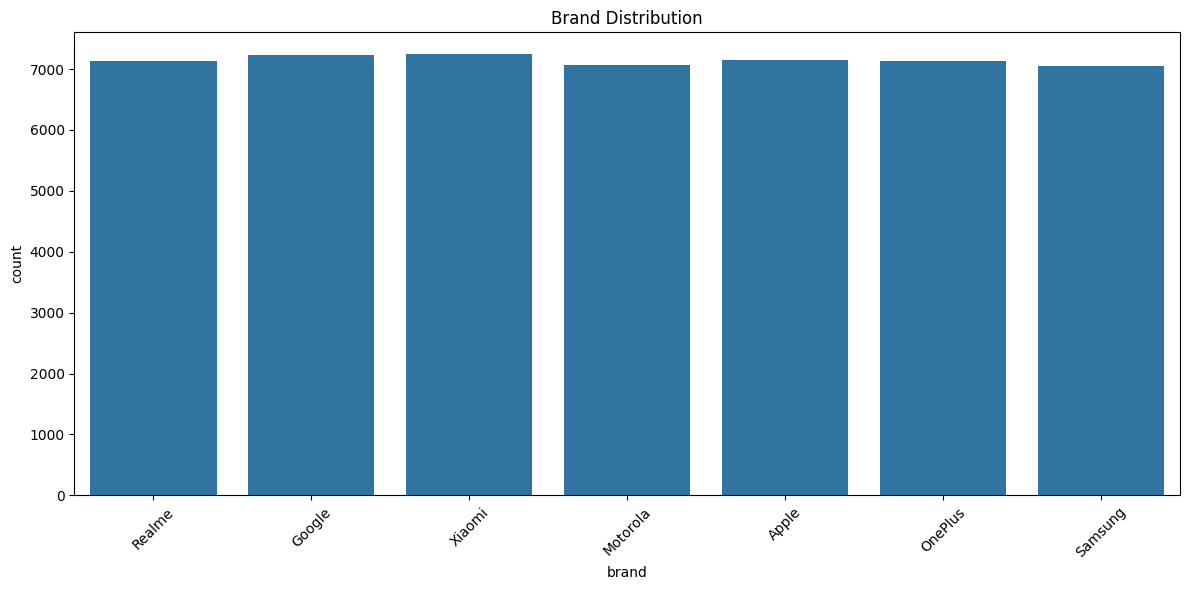

In [17]:
plt.figure(figsize=(12,6))

sns.countplot(x='brand', data=df)

plt.title("Brand Distribution")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Sentiment Distribution

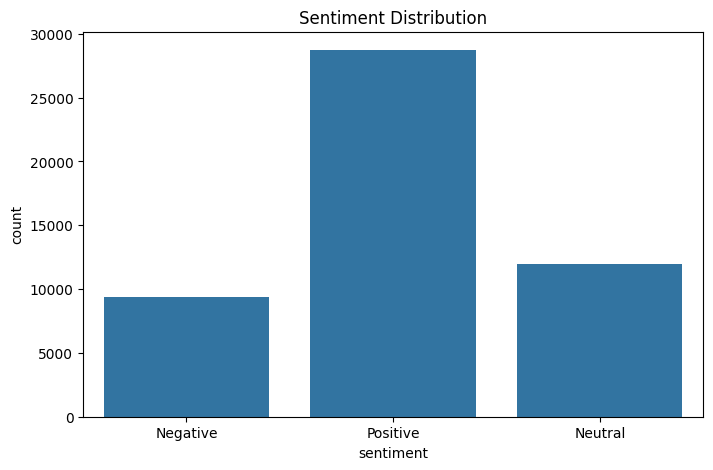

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(x='sentiment', data=df)

plt.title("Sentiment Distribution")

plt.show()

## Price Distribution

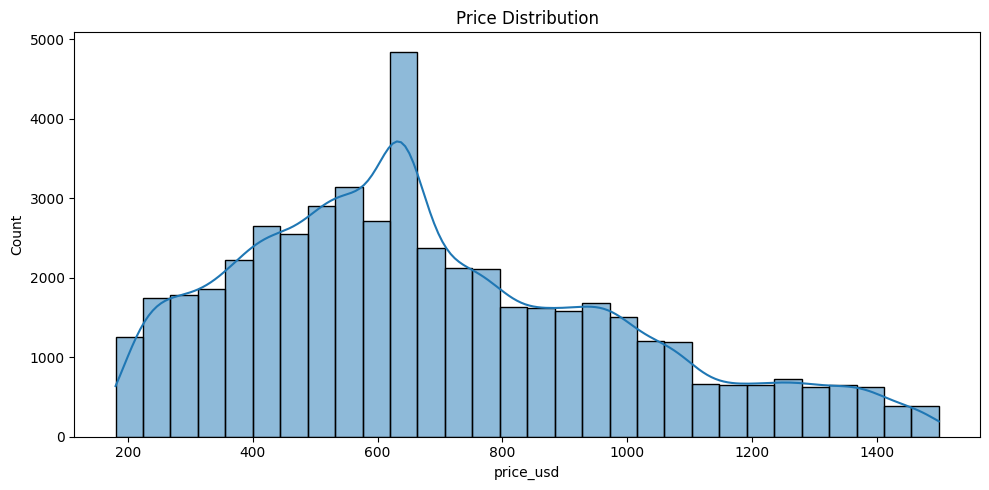

In [19]:
plt.figure(figsize=(10,5))

sns.histplot(df['price_usd'], bins=30, kde=True)

plt.title("Price Distribution")

plt.tight_layout()

plt.show()

## Rating Distribution

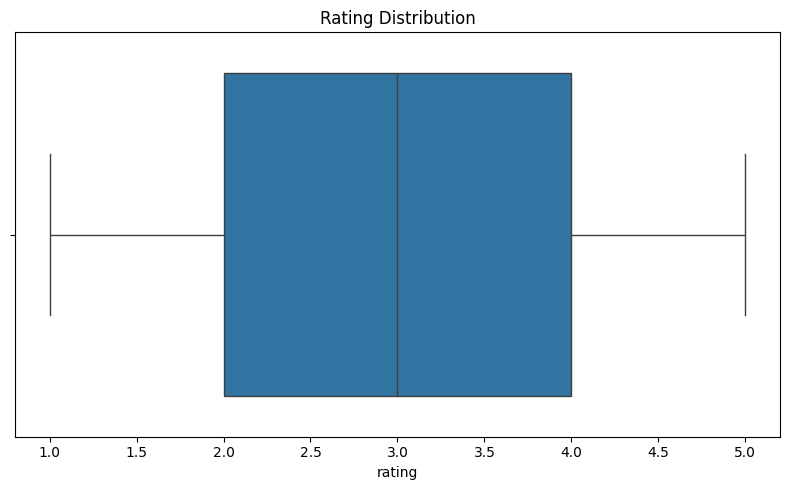

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['rating'])

plt.title("Rating Distribution")

plt.tight_layout()

plt.show()

## Price vs Rating Analysis

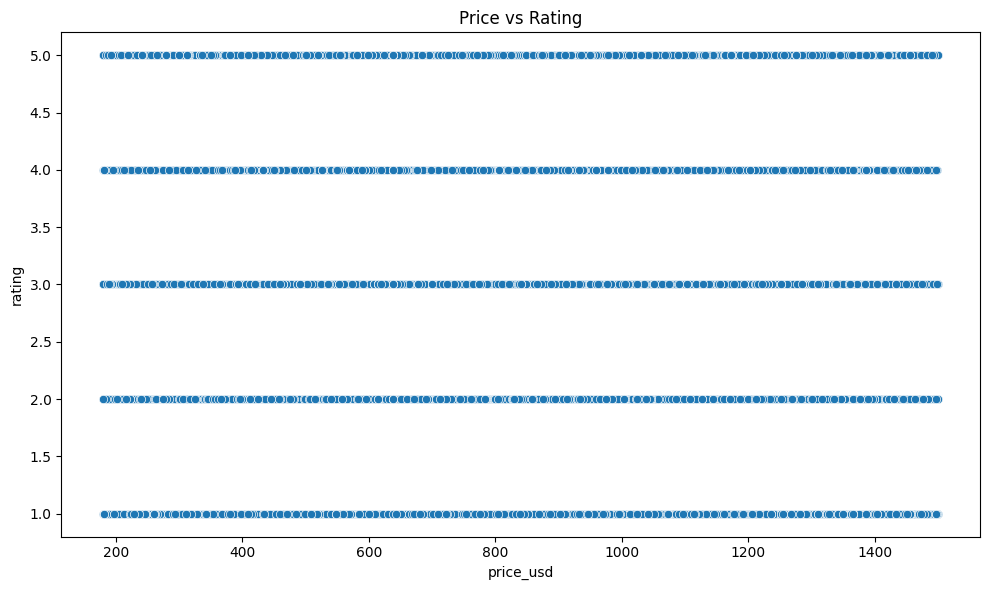

In [21]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='price_usd',
    y='rating',
    data=df
)

plt.title("Price vs Rating")

plt.tight_layout()

plt.show()

## Correlation Heatmap

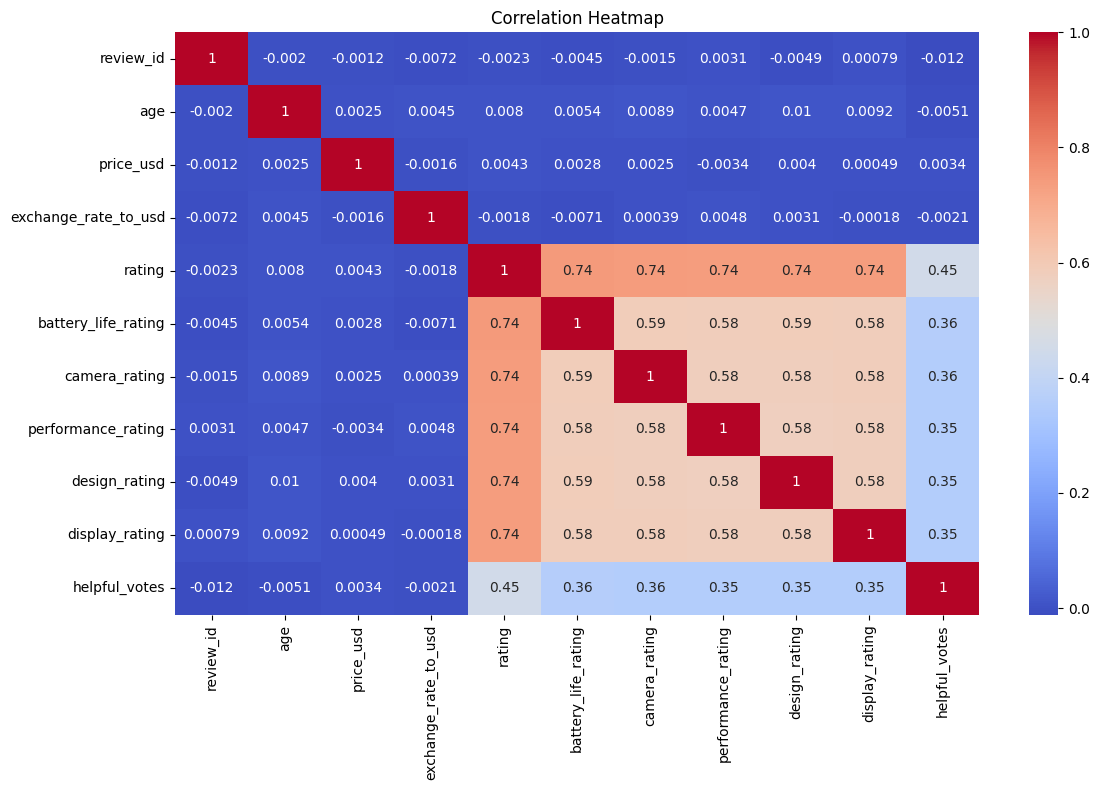

In [22]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

# Feature Engineering and Clustering

## Feature Selection

In [23]:
features = [
    'price_usd',
    'rating',
    'battery_life_rating',
    'camera_rating',
    'performance_rating',
    'design_rating',
    'display_rating',
    'helpful_votes'
]

X = df[features]

X.head()

,price_usd,rating,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes
0,337.31,2.0,1,1,3,2,1,1
1,307.78,4.0,3,2,4,3,2,5
2,864.53,4.0,3,5,3,2,4,8
3,660.94,3.0,1,3,2,1,2,3
4,792.13,3.0,3,3,2,2,1,0


## Feature Scaling

In [24]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Elbow Method



In [25]:
wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

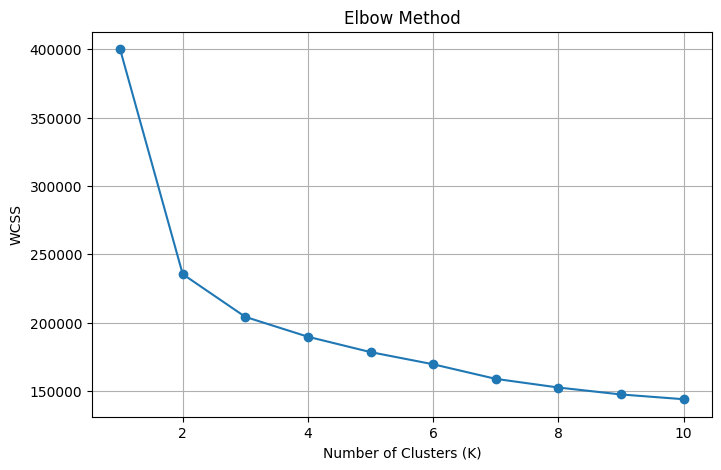

In [26]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

## Elbow Method Analysis

The Elbow Method was used to determine the optimal number of clusters by calculating the Within-Cluster Sum of Squares (WCSS) for different values of K.

The Elbow graph showed a noticeable bend around **K = 3**. After this point, the decrease in WCSS became gradual, indicating that adding more clusters would provide only marginal improvement.

Therefore, **K = 3** was selected as the optimal number of clusters for K-Means clustering.

## Applying K-Means Clustering

In [27]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

In [28]:
df['Cluster'].value_counts()

Cluster
1    17033
0    16729
2    16238
Name: count, dtype: int64

## Cluster Visualization

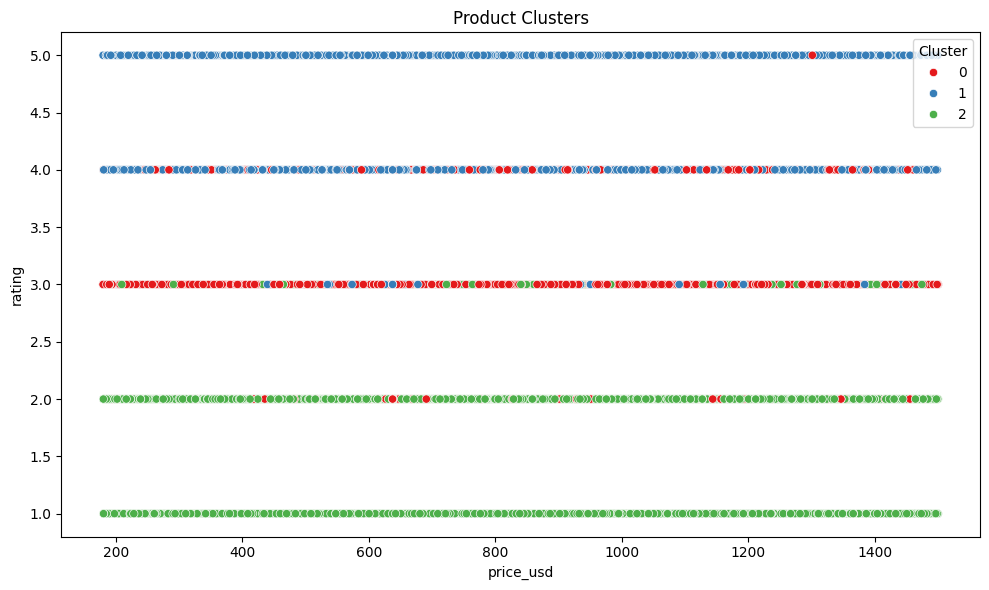

In [29]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='price_usd',
    y='rating',
    hue='Cluster',
    palette='Set1',
    data=df
)

plt.title("Product Clusters")

plt.tight_layout()

plt.show()

## Cluster Summary

In [37]:
cluster_summary = df.groupby('Cluster')[features].mean().round(2)

cluster_summary

,price_usd,rating,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes
Cluster,,,,,,,,
0,686.86,3.21,2.67,2.67,2.68,2.68,2.68,3.73
1,688.40,4.36,3.97,3.97,3.97,3.95,3.97,5.07
2,686.69,1.73,1.45,1.46,1.46,1.46,1.45,2.06


# Cluster-wise Data Analysis

In [40]:
cluster0 = df[df["Cluster"] == 0]

cluster1 = df[df["Cluster"] == 1]

cluster2 = df[df["Cluster"] == 2]

In [41]:
print("Cluster 0 Shape :", cluster0.shape)

print("Cluster 1 Shape :", cluster1.shape)

print("Cluster 2 Shape :", cluster2.shape)

Cluster 0 Shape : (16729, 22)
Cluster 1 Shape : (17033, 22)
Cluster 2 Shape : (16238, 22)


## Cluster 0 EDA

In [42]:
cluster0.head()

,review_id,customer_name,age,brand,model,price_usd,currency,exchange_rate_to_usd,rating,sentiment,...,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source,Cluster
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,BRL,5.70,4.0,Positive,...,3/30/2023,True,3,2,4,3,2,5,Flipkart,0
4,5,Yago Leão,38,Motorola,Edge 50,792.13,BRL,5.70,3.0,Neutral,...,9/29/2023,True,3,3,2,2,1,0,BestBuy,0
6,7,Gina Moore,40,OnePlus,OnePlus 12,420.13,AED,3.67,3.0,Positive,...,3/27/2024,False,3,3,2,1,2,2,eBay,0
8,9,Rosalia Beyer,32,Realme,Realme 12 Pro,275.73,EUR,0.93,4.0,Positive,...,10/4/2024,False,4,3,2,3,3,8,eBay,0
9,10,Valerie Gray,31,OnePlus,OnePlus Nord 3,545.57,AUD,1.53,3.0,Positive,...,2/25/2025,True,2,2,3,3,2,4,BestBuy,0


In [43]:
cluster0.shape

cluster0.describe()

,review_id,age,price_usd,exchange_rate_to_usd,rating,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,Cluster
count,16729.000000,16729.000000,16729.000000,16729.000000,16729.000000,16729.000000,16729.000000,16729.000000,16729.000000,16729.000000,16729.000000,16729.0
mean,24916.440194,30.001016,686.864520,11.836066,3.205153,2.668659,2.668181,2.676251,2.675235,2.680973,3.734234,0.0
std,14363.221570,8.912948,302.422843,26.274889,0.508295,0.980817,0.985702,0.993781,0.984169,0.993172,2.325400,0.0
min,2.000000,18.000000,180.020000,0.780000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.0
25%,12518.000000,23.000000,460.150000,1.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,0.0
50%,24913.000000,29.000000,637.585000,1.380000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,0.0
75%,37318.000000,36.000000,883.940000,5.700000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,5.000000,0.0
max,49999.000000,65.000000,1499.820000,83.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,16.000000,0.0


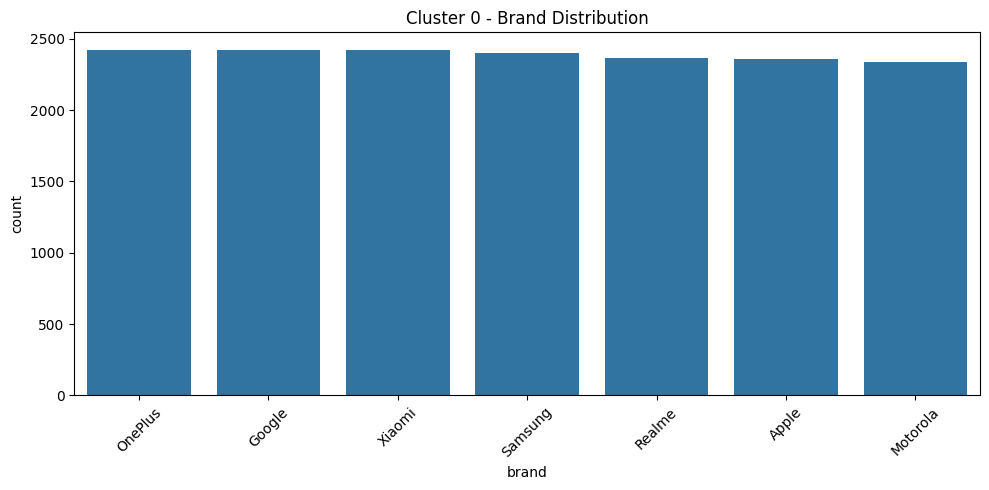

In [44]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="brand",
    data=cluster0,
    order=cluster0["brand"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Cluster 0 - Brand Distribution")

plt.tight_layout()

plt.show()

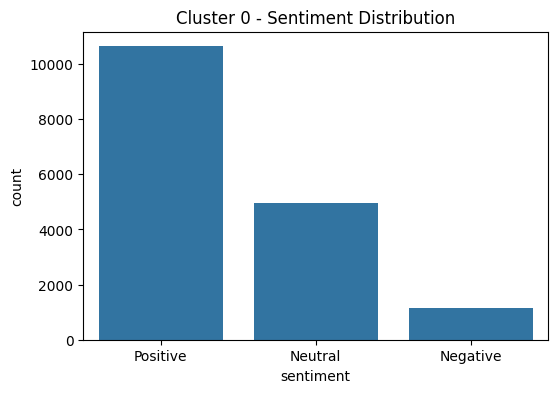

In [45]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="sentiment",
    data=cluster0
)

plt.title("Cluster 0 - Sentiment Distribution")

plt.show()

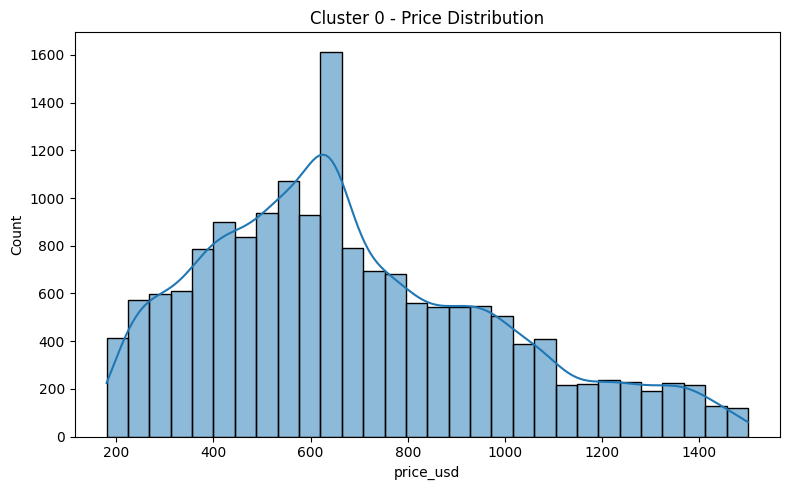

In [46]:
plt.figure(figsize=(8,5))

sns.histplot(
    cluster0["price_usd"],
    bins=30,
    kde=True
)

plt.title("Cluster 0 - Price Distribution")

plt.tight_layout()

plt.show()

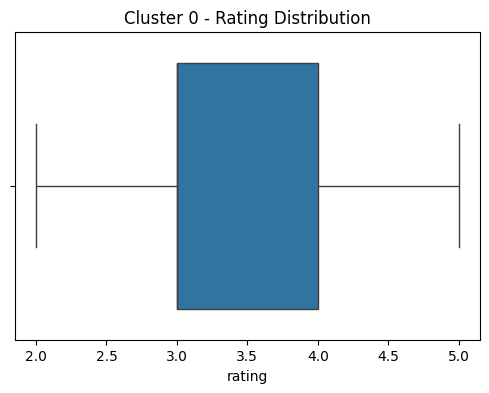

In [47]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x=cluster0["rating"]
)

plt.title("Cluster 0 - Rating Distribution")

plt.show()

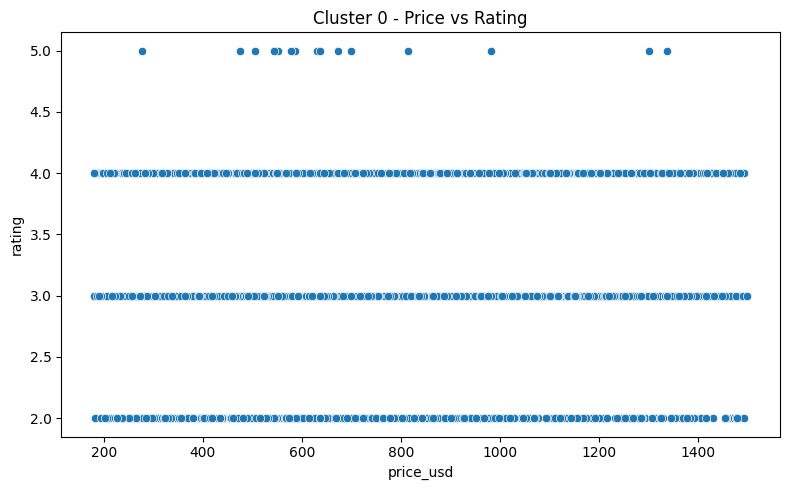

In [48]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="price_usd",
    y="rating",
    data=cluster0
)

plt.title("Cluster 0 - Price vs Rating")

plt.tight_layout()

plt.show()

In [49]:
cluster0["brand"].value_counts().head(10)

brand
OnePlus     2425
Google      2422
Xiaomi      2420
Samsung     2398
Realme      2369
Apple       2358
Motorola    2337
Name: count, dtype: int64

In [50]:
cluster0[
    [
        "battery_life_rating",
        "camera_rating",
        "performance_rating",
        "design_rating",
        "display_rating"
    ]
].mean().round(2)

battery_life_rating    2.67
camera_rating          2.67
performance_rating     2.68
design_rating          2.68
display_rating         2.68
dtype: float64

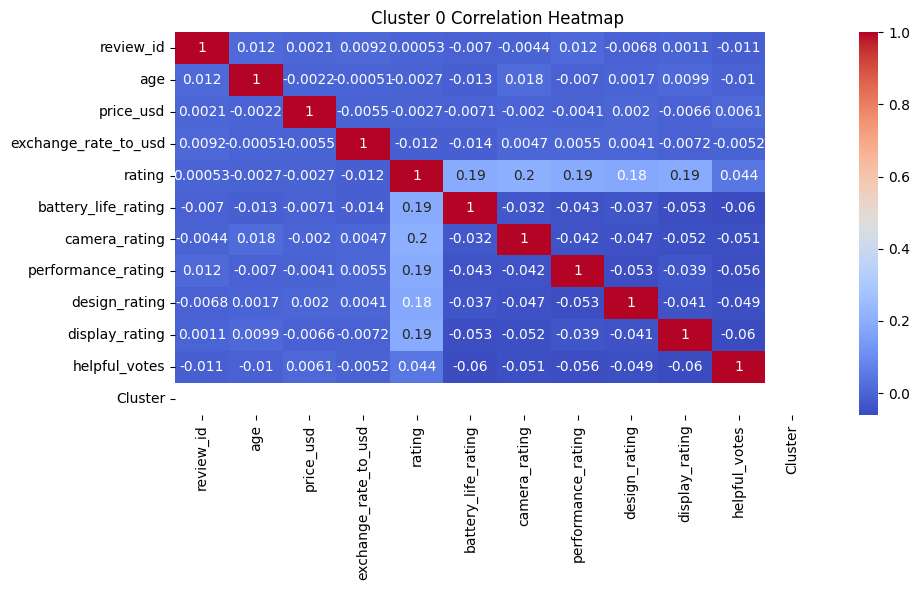

In [51]:
plt.figure(figsize=(10,6))

sns.heatmap(
    cluster0.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Cluster 0 Correlation Heatmap")

plt.tight_layout()

plt.show()

### Cluster 1 EDA

In [52]:
print("Cluster 1 Shape :", cluster1.shape)

Cluster 1 Shape : (17033, 22)


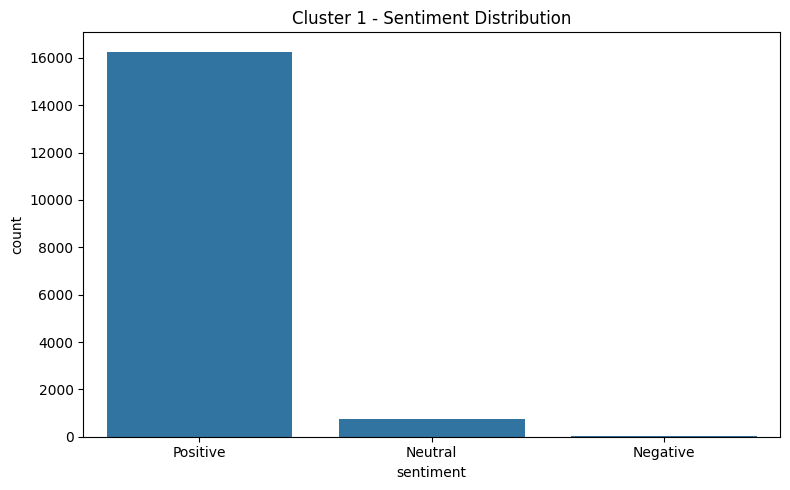

In [53]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='sentiment',
    data=cluster1
)

plt.title("Cluster 1 - Sentiment Distribution")

plt.tight_layout()

plt.show()

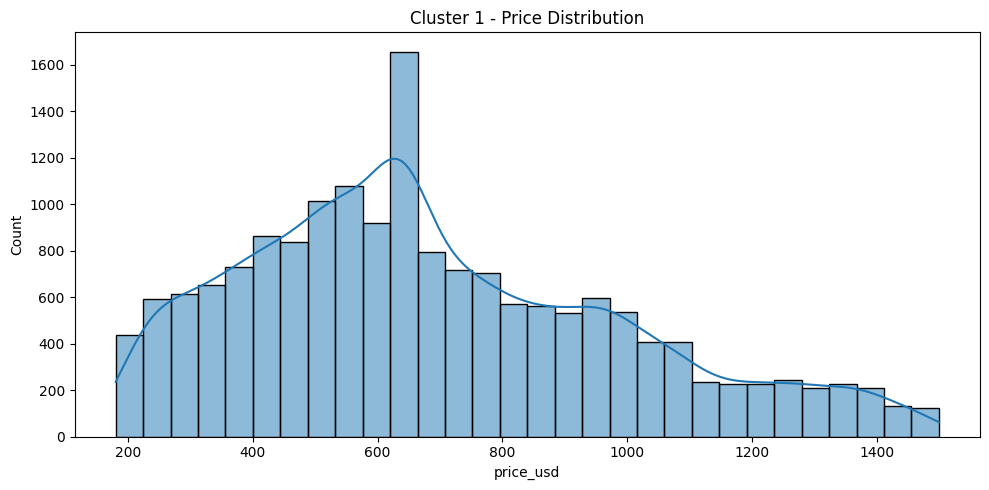

In [54]:
plt.figure(figsize=(10,5))

sns.histplot(
    cluster1['price_usd'],
    bins=30,
    kde=True
)

plt.title("Cluster 1 - Price Distribution")

plt.tight_layout()

plt.show()

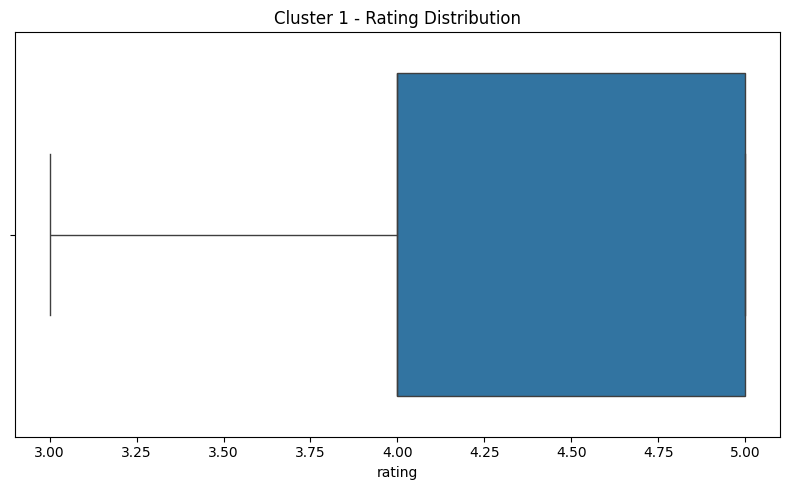

In [55]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=cluster1['rating']
)

plt.title("Cluster 1 - Rating Distribution")

plt.tight_layout()

plt.show()

In [56]:
cluster1['brand'].value_counts().head(10)

brand
Realme      2482
Google      2479
Apple       2465
Xiaomi      2453
OnePlus     2432
Motorola    2385
Samsung     2337
Name: count, dtype: int64

In [57]:
cluster2[
    [
        'battery_life_rating',
        'camera_rating',
        'performance_rating',
        'design_rating',
        'display_rating'
    ]
].mean().round(2)

battery_life_rating    1.45
camera_rating          1.46
performance_rating     1.46
design_rating          1.46
display_rating         1.45
dtype: float64

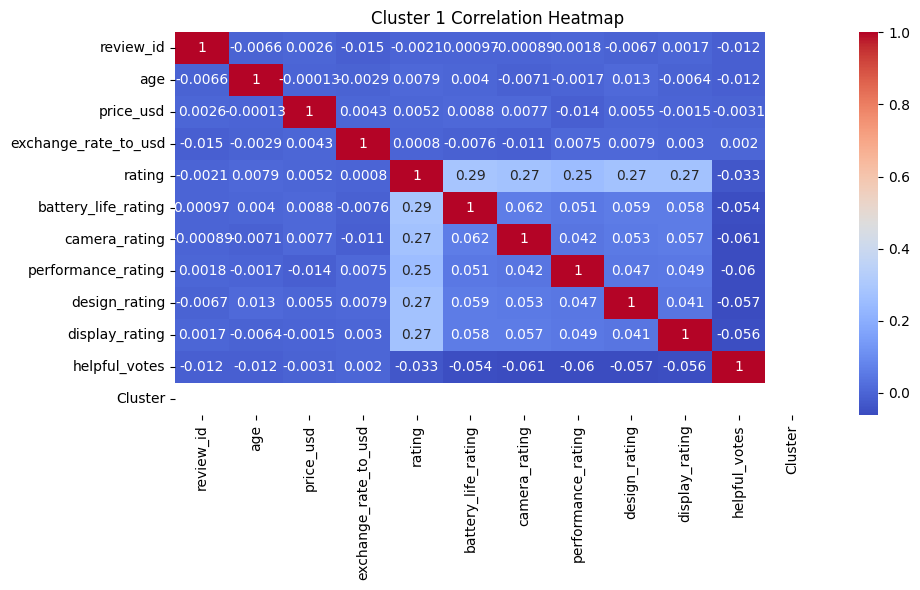

In [58]:
plt.figure(figsize=(10,6))

sns.heatmap(
    cluster1.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Cluster 1 Correlation Heatmap")

plt.tight_layout()

plt.show()

## Cluster 2 EDA

In [59]:
print("Cluster 2 Shape :", cluster2.shape)

Cluster 2 Shape : (16238, 22)


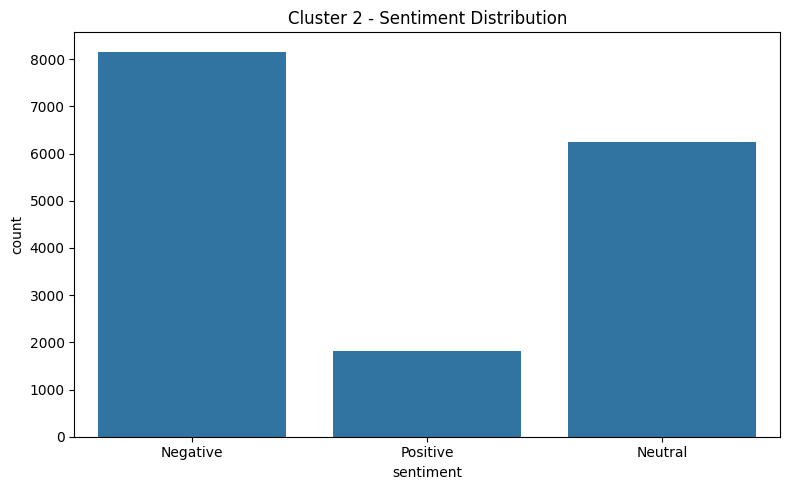

In [60]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='sentiment',
    data=cluster2
)

plt.title("Cluster 2 - Sentiment Distribution")

plt.tight_layout()

plt.show()

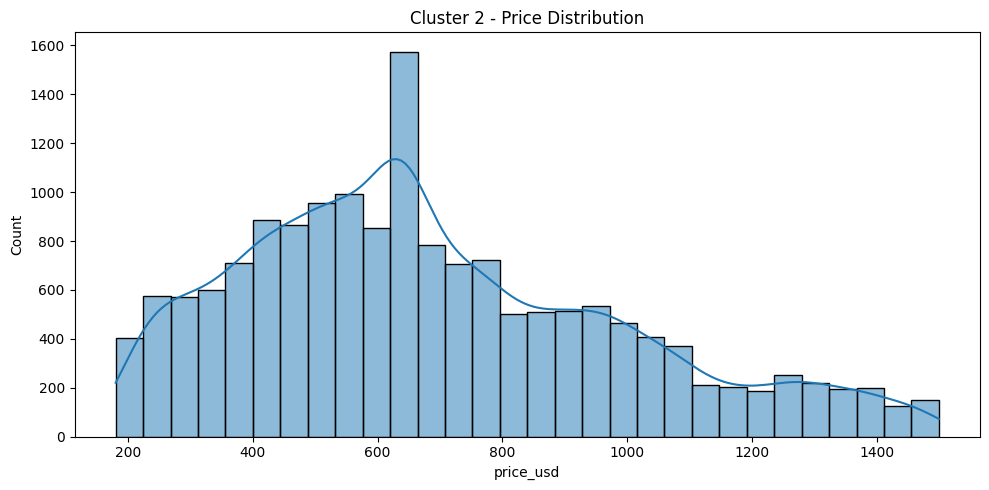

In [61]:
plt.figure(figsize=(10,5))

sns.histplot(
    cluster2['price_usd'],
    bins=30,
    kde=True
)

plt.title("Cluster 2 - Price Distribution")

plt.tight_layout()

plt.show()

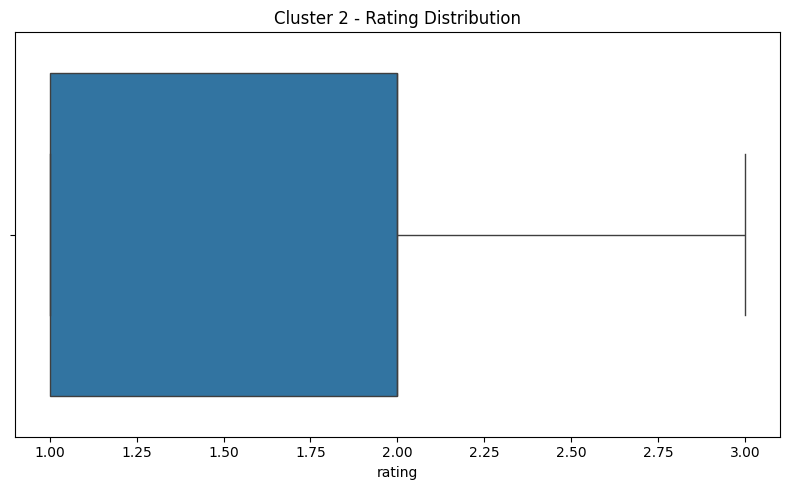

In [62]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=cluster2['rating']
)

plt.title("Cluster 2 - Rating Distribution")

plt.tight_layout()

plt.show()

In [63]:
cluster2['brand'].value_counts().head(10)

brand
Xiaomi      2368
Motorola    2339
Google      2333
Apple       2321
Samsung     2317
Realme      2281
OnePlus     2279
Name: count, dtype: int64

In [64]:
cluster2[
    [
        'battery_life_rating',
        'camera_rating',
        'performance_rating',
        'design_rating',
        'display_rating'
    ]
].mean().round(2)

battery_life_rating    1.45
camera_rating          1.46
performance_rating     1.46
design_rating          1.46
display_rating         1.45
dtype: float64

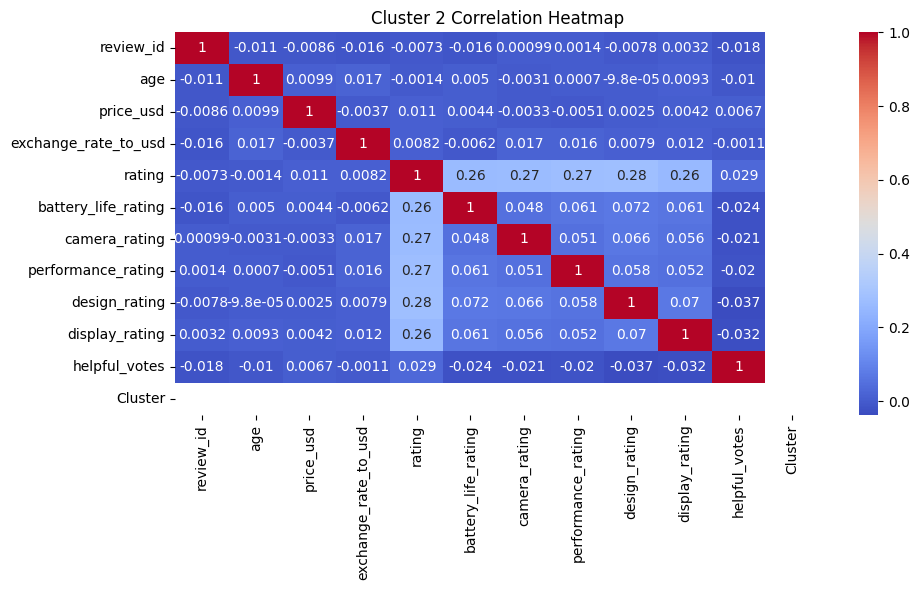

In [65]:
plt.figure(figsize=(10,6))

sns.heatmap(
    cluster2.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Cluster 2 Correlation Heatmap")

plt.tight_layout()

plt.show()

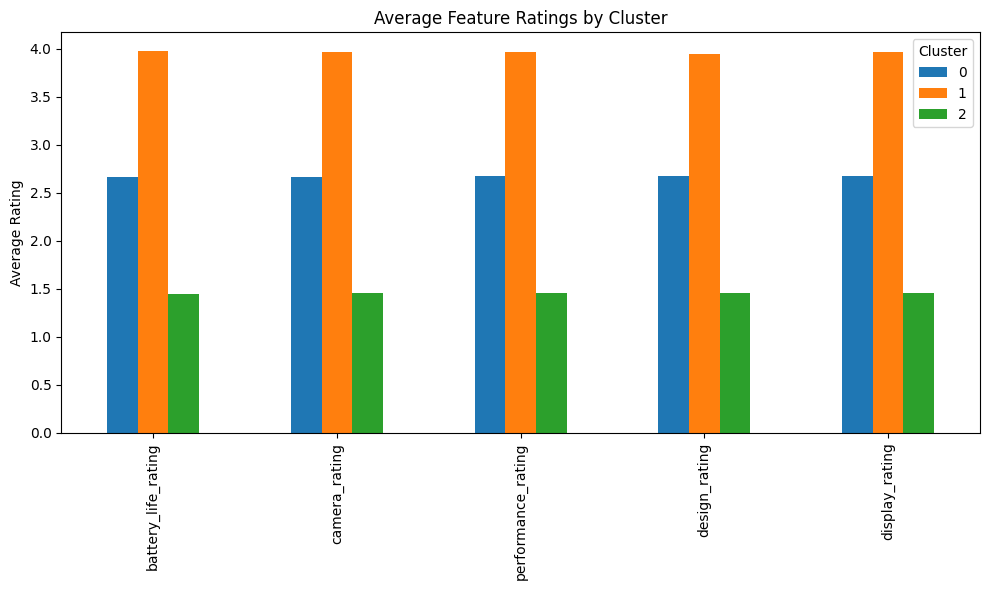

In [39]:
feature_summary = df.groupby('Cluster')[
    [
        'battery_life_rating',
        'camera_rating',
        'performance_rating',
        'design_rating',
        'display_rating'
    ]
].mean()

feature_summary.T.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Average Feature Ratings by Cluster")
plt.ylabel("Average Rating")
plt.tight_layout()

plt.show()

## Cluster Insights

### Cluster 0 – Average Performance Mobiles

This cluster represents smartphones with moderate customer ratings and balanced feature scores. The products provide average battery life, camera quality, display quality, and overall performance, making them suitable for everyday users. Most devices in this segment offer a balanced combination of features and user satisfaction.

### Cluster 1 – High Performance Mobiles

This cluster contains smartphones with the highest ratings across battery life, camera, display, design, and performance. The devices in this segment received higher customer satisfaction and represent the best-performing smartphones identified through clustering.

### Cluster 2 – Low Performance Mobiles

This cluster consists of smartphones with the lowest customer ratings and feature scores. These devices exhibit comparatively lower battery, camera, display, and performance ratings, indicating lower customer satisfaction than the other clusters.

# Recommendation System

## Feature Selection for Recommendation

In [31]:
recommend_features = [
    'price_usd',
    'rating',
    'battery_life_rating',
    'camera_rating',
    'performance_rating',
    'design_rating',
    'display_rating'
]

recommend_data = df[recommend_features]

## Cosine Similarity

In [32]:
similarity = cosine_similarity(recommend_data)

## Recommendation Function

In [33]:
def recommend_mobile(index):

    distances = list(enumerate(similarity[index]))

    similar_products = sorted(
        distances,
        key=lambda x: x[1],
        reverse=True
    )

    recommended = similar_products[1:6]

    for i in recommended:
        print(
            df.iloc[i[0]]['brand'],
            "-",
            df.iloc[i[0]]['model']
        )

## Testing Recommendation System

In [34]:
recommend_mobile(10)

OnePlus - OnePlus 12
Xiaomi - Mi 13 Pro
Xiaomi - Redmi Note 13
Xiaomi - Poco X6
Motorola - Razr 40


## Recommendation System Insights

The recommendation system uses cosine similarity to identify products with similar specifications and ratings.

Based on selected product features such as price, ratings, battery, camera, display, and performance, the system recommends similar smartphones to users.

This helps users discover related products with comparable performance and customer satisfaction.

# Exporting Final Dataset

In [35]:
df.to_csv("final_mobile_reviews.csv", index=False)

# Conclusion

This project successfully implemented a Mobile Product Segmentation and Recommendation System using Python and Machine Learning.

The dataset was cleaned and preprocessed by handling missing values and selecting relevant product features. Exploratory Data Analysis (EDA) was performed to understand customer ratings, product specifications, and market trends.

The Elbow Method was used to determine the optimal number of clusters, and K-Means clustering with K = 3 segmented smartphones into Low Performance, Average Performance, and High Performance groups based on customer ratings and feature scores.

Finally, a recommendation system using Cosine Similarity was developed to recommend similar smartphones based on their specifications and ratings, helping users discover products with comparable characteristics.
